In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [2]:
df=pd.read_csv("/content/sample_data/insurance.csv")
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [7]:
df.shape

(1338, 7)

In [23]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


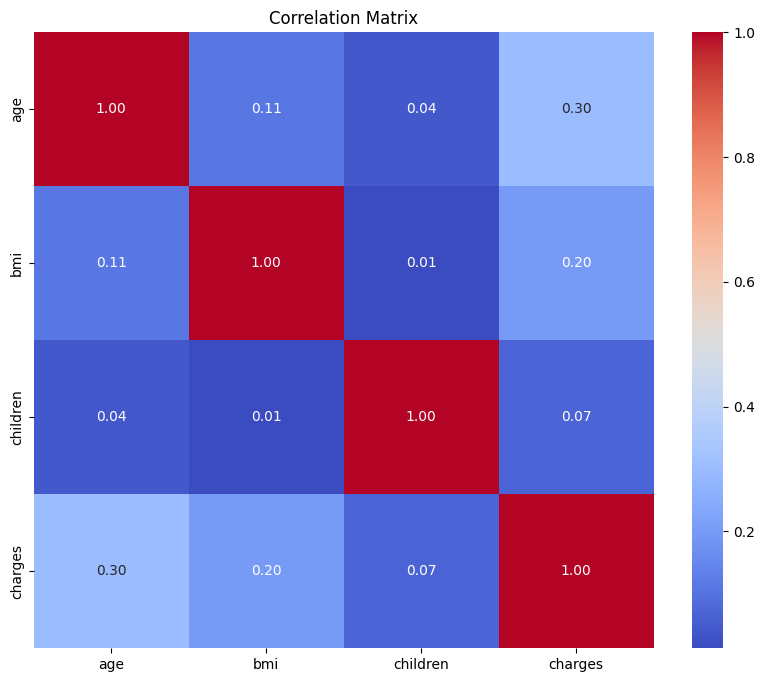

In [25]:
#heatmap to check correlation
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [17]:
#Seperation
X=df[['bmi']]
y=df['charges']

In [18]:
#split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
#Train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [21]:
#make predictions
y_pred = model.predict(X_test)
print(y_pred)

[11232.66307168 13134.01812818 11903.72956221 11456.35190186
 13879.64756211 18188.60081709 10188.78186419 16228.38027896
  8138.3009209  12612.07752444 10928.52474995 13357.70695836
 12965.27041419 17972.7607178  17411.57645964 16634.55210218
 18102.26477738 15728.02368515 12360.91813617 11903.72956221
 10732.30647786 14146.50441214 13283.14401497 16974.00971289
 12388.38869426 14177.89933568 15127.59577257 13283.14401497
 11791.88514712 13181.11051348 12851.46381638 13842.36609041
 15037.33536741  9182.18212839 13126.1693973  16974.00971289
 11713.39783829 13086.92574288 10822.56688302 15166.83942698
 12576.75823546 13655.95873193 15402.30135349 11344.50748677
 15382.67952628 12145.07803688 14550.71405264 10889.28109553
 15469.015566   16418.71200289 15598.51962557 12878.93437447
 17607.79473172 11605.47778864 14864.66328797 13954.2105055
 11344.50748677 14848.96582621 14342.72268423 14401.58816585
 13832.55517681 18274.93685681 15520.03231674 11158.10012829
 13469.55137345 11530.914

In [26]:
#Actual vs predicted
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result)

           Actual     Predicted
764    9095.06825  11232.663072
887    5272.17580  13134.018128
890   29330.98315  11903.729562
1293   9301.89355  11456.351902
259   33750.29180  13879.647562
...           ...           ...
109   47055.53210  15123.671407
575   12222.89830  12015.573977
535    6067.12675  12351.107223
543   63770.42801  19958.489631
846    9872.70100  14774.402883

[268 rows x 2 columns]


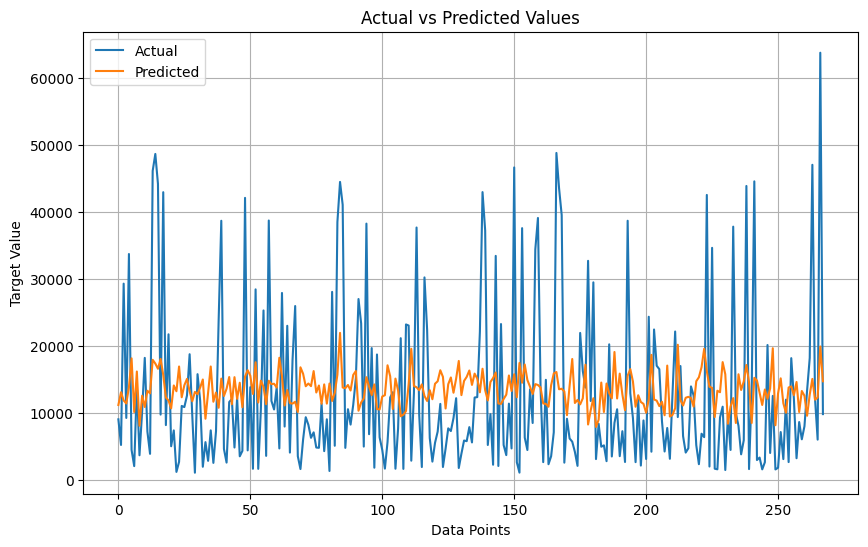

In [27]:
#line graph to visaualize predict with Actual
plt.figure(figsize=(10,6))

sns.lineplot(x=range(len(y_test)),
             y=y_test.values,
             label='Actual')

sns.lineplot(x=range(len(y_pred)),
             y=y_pred,
             label='Predicted')

plt.title('Actual vs Predicted Values')
plt.xlabel('Data Points')
plt.ylabel('Target Value')
plt.grid(True)

plt.show()

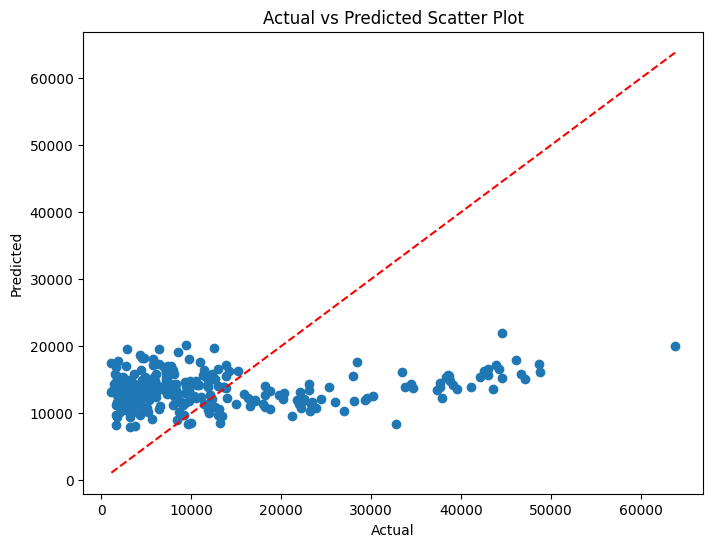

In [30]:
#Scatter Plot
#if points lie close to the diagnol line/Regression line , your model is performing well.
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Scatter Plot')
plt.show()

In [32]:
#it tell how well the model explains the variance in the data
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.03970193117941878


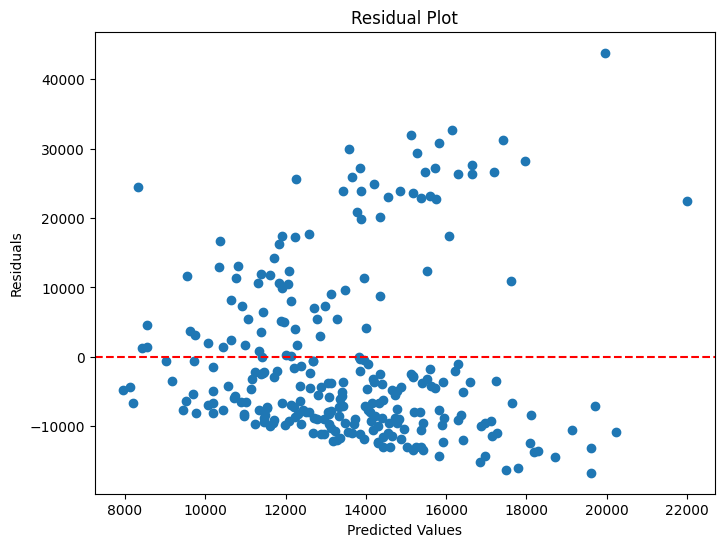

In [33]:
# Residuals represent the difference between actual and predicted values
# They help us understand the prediction error of the model
#Random scatter around 0 → Good model
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

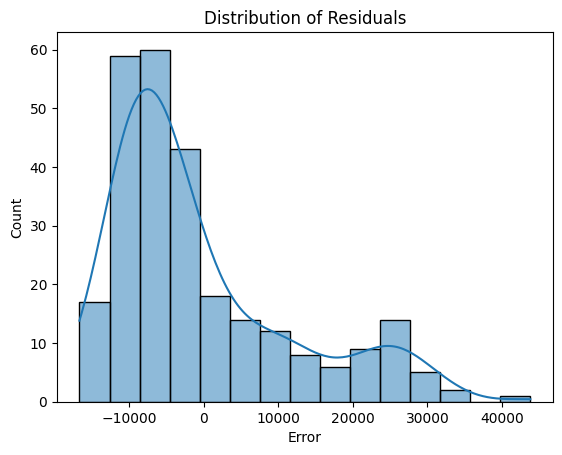

In [34]:
#Bell Shaped-> Good Model
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Error')
plt.show()